**IMPORTING LIBRARIRES & LOADING DATASETS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import RFECV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, brier_score_loss)

# Handling imbalanced data
from imblearn.combine import SMOTETomek

# Advanced models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install catboost
from catboost import CatBoostClassifier

# Explainability
import shap

# Bayesian optimization
!pip install optuna
import optuna

# Saving model
import joblib

# 1. LOAD DATASET

# Loading the two provided datasets
df_uci = pd.read_csv('/content/drive/MyDrive/UCI_Dataset.csv')
df_binary = pd.read_csv('/content/drive/MyDrive/Diabetes_Binary_Dataset.csv')

print(f"UCI Dataset shape: {df_uci.shape}")
print(df_uci.head())

print(f"Diabetes Binary Dataset shape: {df_binary.shape}")
print(df_binary.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.4 MB/s eta 0:00:00
UCI Dataset shape: (520, 17)
   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No          

**EXPLORATORY DATA ANALYSIS(EDA)**


==================== UCI Dataset EDA ====================

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object


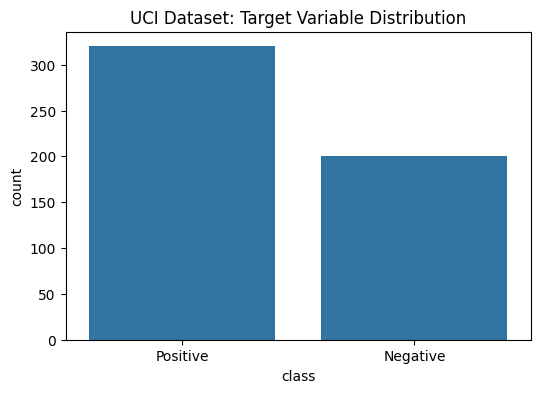

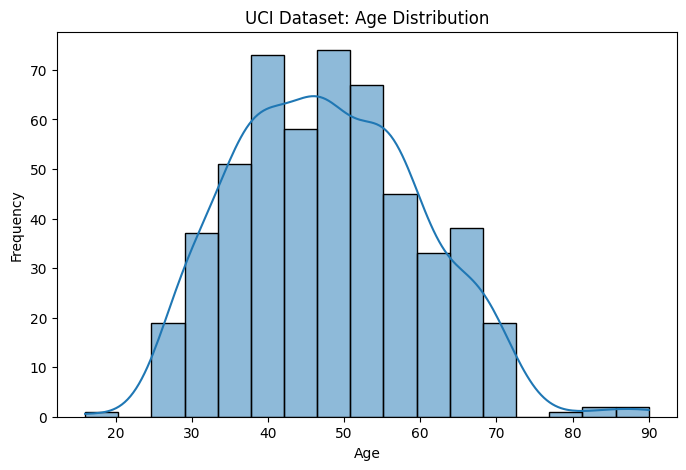

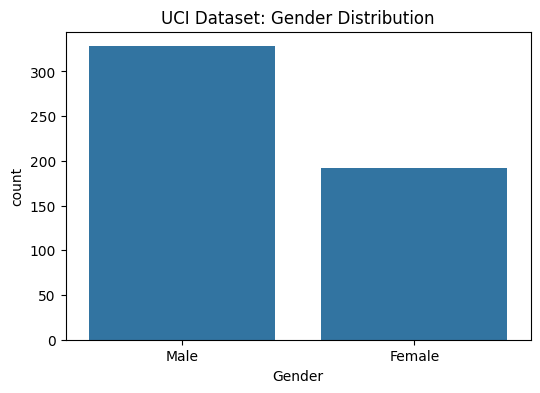

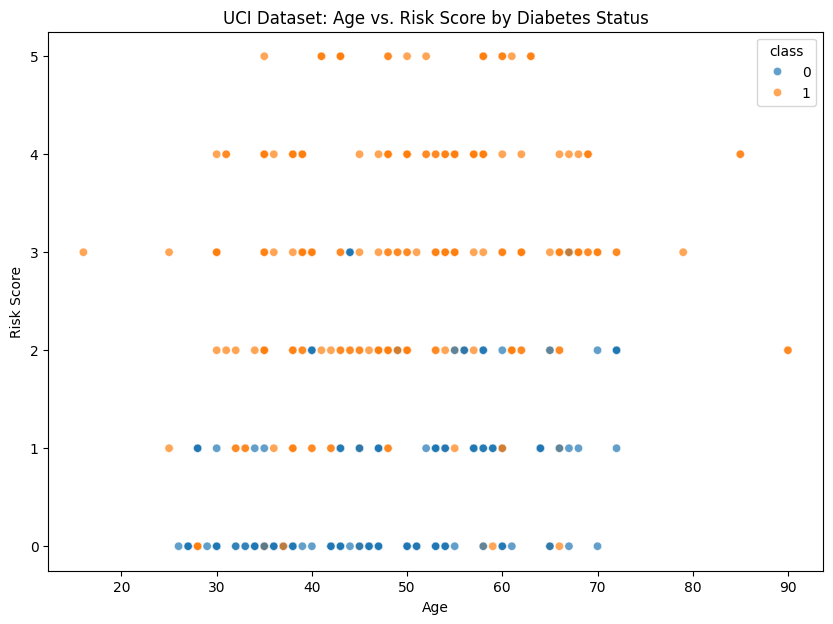

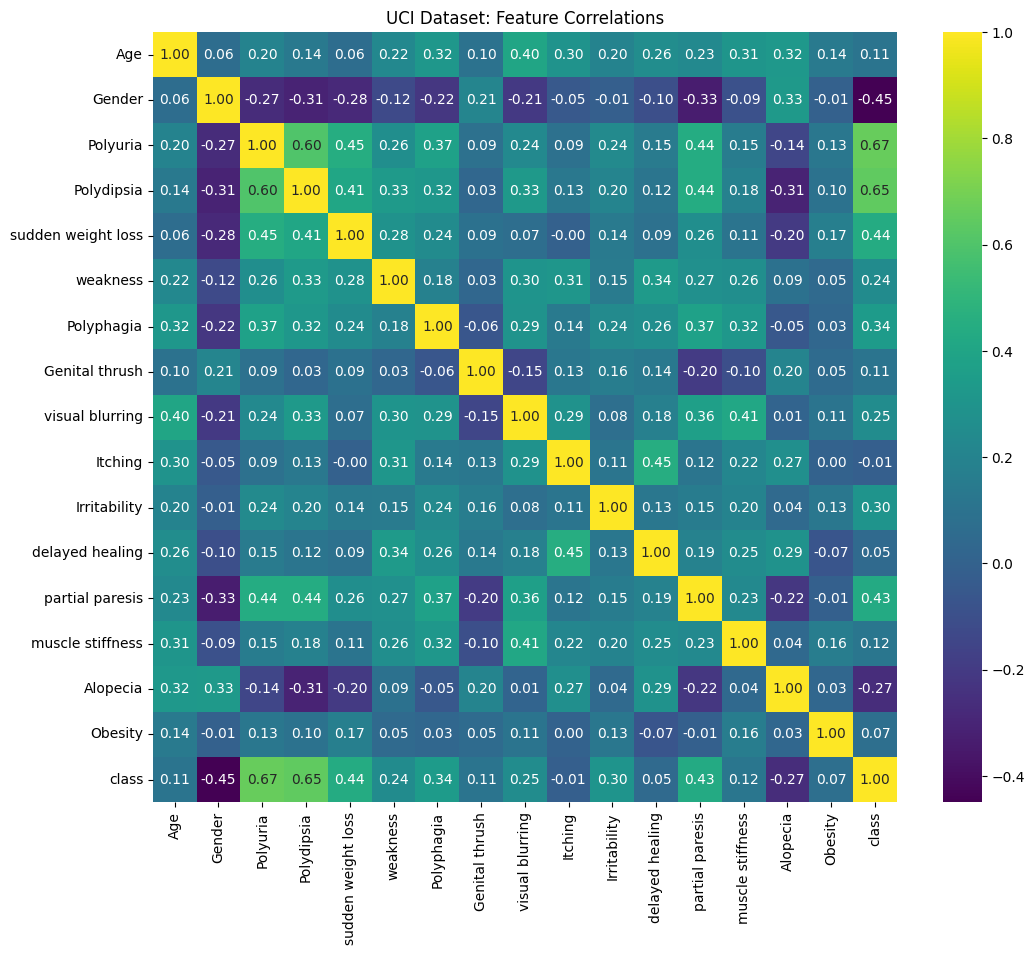


==================== Diabetes Binary Dataset EDA ====================

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost  

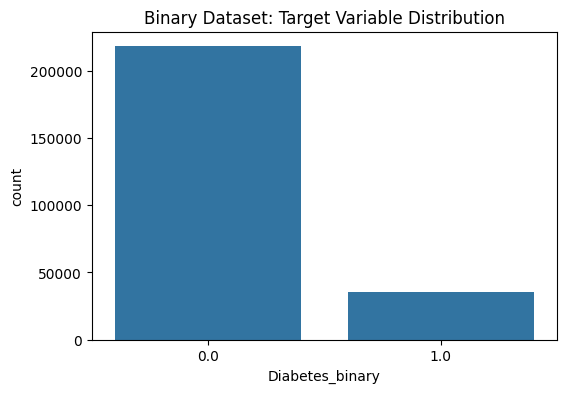

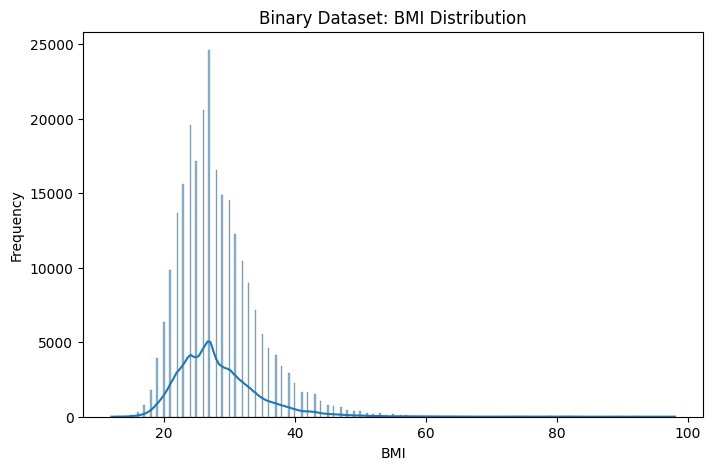

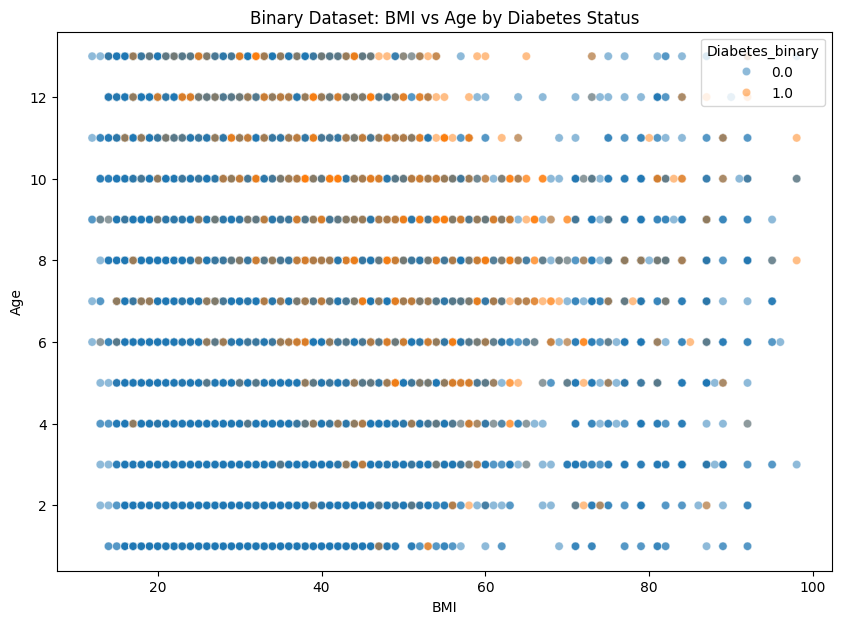

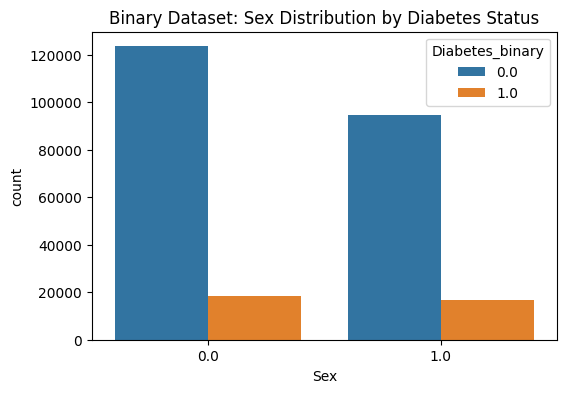

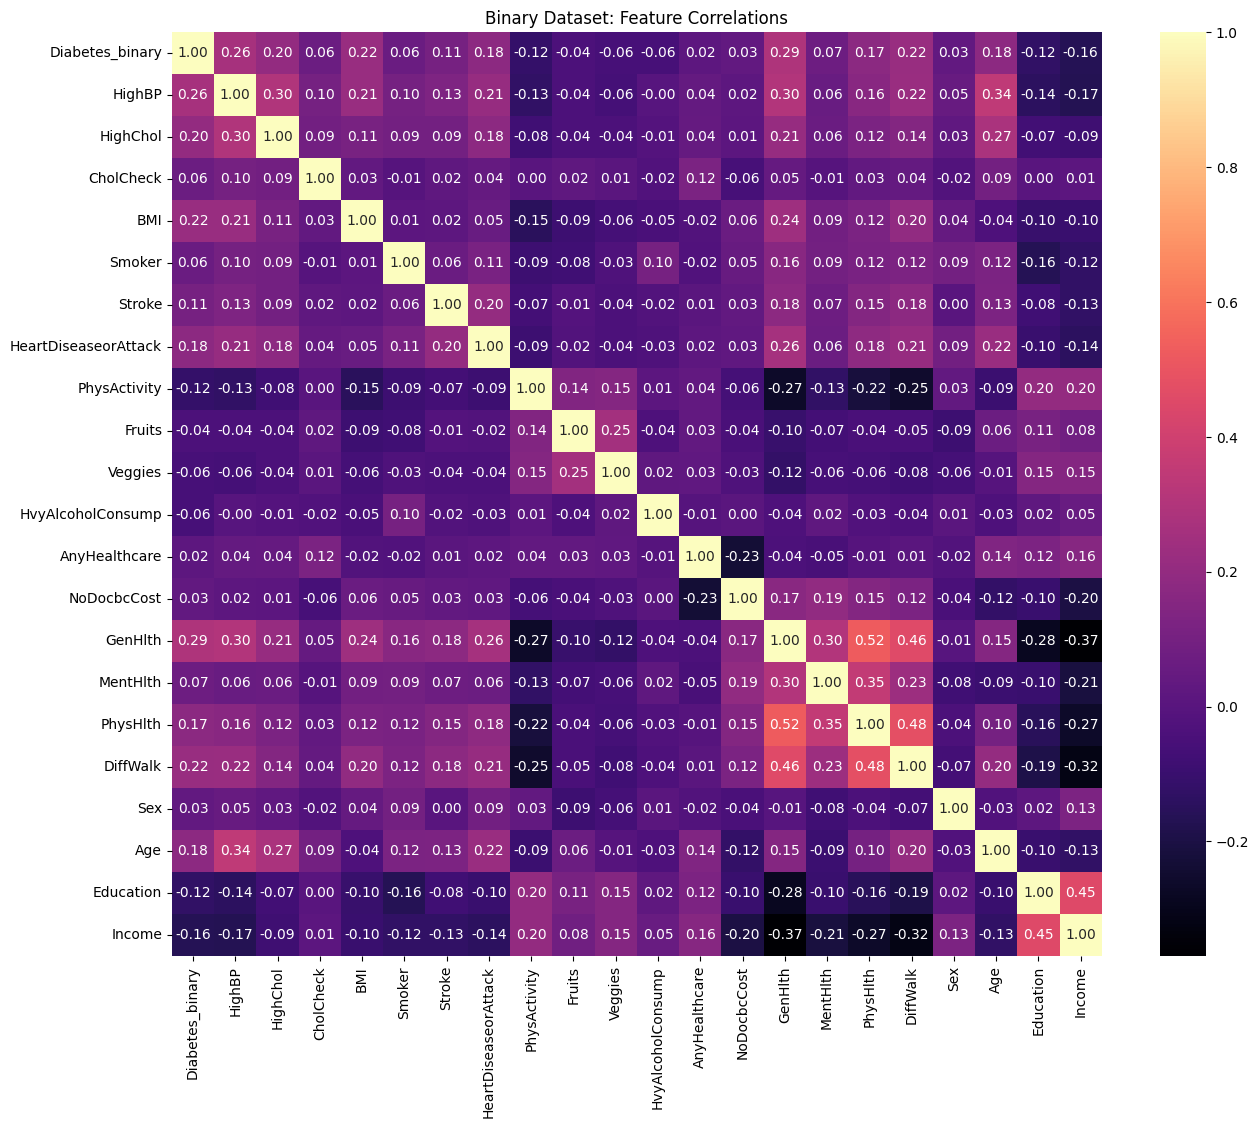

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load datasets to ensure they are defined if previous cells weren't run
df_uci = pd.read_csv('/content/drive/MyDrive/UCI_Dataset.csv')
df_binary = pd.read_csv('/content/drive/MyDrive/Diabetes_Binary_Dataset.csv')

# --- UCI DATASET EDA ---
print("\n" + "="*20 + " UCI Dataset EDA " + "="*20)
print("\n--- Basic Info ---")
print(df_uci.info())
print("\n--- Descriptive Statistics ---")
print(df_uci.describe())
print("\n--- Class Distribution ---")
print(df_uci['class'].value_counts())

# Visualizations for UCI
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df_uci)
plt.title('UCI Dataset: Target Variable Distribution')
plt.show()

# Histogram for Age
plt.figure(figsize=(8, 5))
sns.histplot(df_uci['Age'], kde=True)
plt.title('UCI Dataset: Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Bar chart for Gender
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df_uci)
plt.title('UCI Dataset: Gender Distribution')
plt.show()

le = LabelEncoder()
df_uci_temp = df_uci.copy()
for col in df_uci_temp.columns:
    if df_uci_temp[col].dtype == 'object':
        df_uci_temp[col] = le.fit_transform(df_uci_temp[col])

symptom_cols_for_eda = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'Polyphagia', 'Obesity']
# Ensure all symptom_cols_for_eda are present in df_uci_temp before summing
existing_symptom_cols = [col for col in symptom_cols_for_eda if col in df_uci_temp.columns]
if existing_symptom_cols:
    df_uci_temp['Risk_Score'] = df_uci_temp[existing_symptom_cols].sum(axis=1)
else:
    df_uci_temp['Risk_Score'] = 0 # Default if no symptom columns exist

# Scatterplot for Age vs. Risk_Score, colored by class
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age', y='Risk_Score', hue='class', data=df_uci_temp, alpha=0.7)
plt.title('UCI Dataset: Age vs. Risk Score by Diabetes Status')
plt.xlabel('Age')
plt.ylabel('Risk Score')
plt.show()

# Heatmap (Requires encoding categorical strings to numeric)
df_uci_encoded = df_uci.copy()
for col in df_uci_encoded.columns:
    if df_uci_encoded[col].dtype == 'object':
        df_uci_encoded[col] = LabelEncoder().fit_transform(df_uci_encoded[col])

plt.figure(figsize=(12, 10))
sns.heatmap(df_uci_encoded.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('UCI Dataset: Feature Correlations')
plt.show()

# --- DIABETES BINARY DATASET EDA ---
print("\n" + "="*20 + " Diabetes Binary Dataset EDA " + "="*20)
print("\n--- Basic Info ---")
print(df_binary.info())
print("\n--- Descriptive Statistics ---")
print(df_binary.describe())
print("\n--- Class Distribution ---")
print(df_binary['Diabetes_binary'].value_counts())

# Visualizations for Binary
plt.figure(figsize=(6, 4))
sns.countplot(x='Diabetes_binary', data=df_binary)
plt.title('Binary Dataset: Target Variable Distribution')
plt.show()

# Histogram for BMI
plt.figure(figsize=(8, 5))
sns.histplot(df_binary['BMI'], kde=True)
plt.title('Binary Dataset: BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

# Scatterplot for BMI vs Age, colored by Diabetes_binary
plt.figure(figsize=(10, 7))
sns.scatterplot(x='BMI', y='Age', hue='Diabetes_binary', data=df_binary, alpha=0.5)
plt.title('Binary Dataset: BMI vs Age by Diabetes Status')
plt.xlabel('BMI')
plt.ylabel('Age')
plt.show()

# Bar chart for Sex
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=df_binary, hue='Diabetes_binary')
plt.title('Binary Dataset: Sex Distribution by Diabetes Status')
plt.show()

plt.figure(figsize=(15, 12))
sns.heatmap(df_binary.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Binary Dataset: Feature Correlations')
plt.show()

**ADVANCED DATA PREPROCESSING**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer # Added import for SimpleImputer
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures

# ==========================================
# 3. PREPROCESSING FOR UCI DATASET
# ==========================================
print("\n--- Preprocessing UCI Dataset ---")

# Re-load datasets to ensure they are defined if previous cells weren't run
# This is to address NameError if this cell is run independently
df_uci = pd.read_csv('/content/drive/MyDrive/UCI_Dataset.csv')
df_binary = pd.read_csv('/content/drive/MyDrive/Diabetes_Binary_Dataset.csv')

# 3.1 & 3.2 Label Encoding & Missing Values
# First, convert categorical strings to numeric for processing
le = LabelEncoder()
for col in df_uci.columns:
    if df_uci[col].dtype == 'object':
        df_uci[col] = le.fit_transform(df_uci[col])

# Add new features to UCI dataset with default values (as synthetic data)
df_uci['tingling_numbness'] = 0  # Binary, default to no
df_uci['fasting_glucose'] = 90.0 # Normal fasting glucose
df_uci['random_glucose'] = 120.0 # Normal random glucose
df_uci['hba1c'] = 5.5            # Normal HbA1c

# UCI only has 'Age' as a continuous variable; symptoms are binary (0/1)
# Checking for 0 in Age (medically impossible)
df_uci['Age'] = df_uci['Age'].replace(0, np.nan)
imputer_uci = SimpleImputer(strategy='median')
df_uci[['Age']] = imputer_uci.fit_transform(df_uci[['Age']])

# Drop 'Irritability' and 'muscle stiffness' as requested implicitly by the user in a previous turn by removing them from the UI.
# While not explicitly asked to remove from UCI, it's good practice for consistency.
# Check if columns exist before dropping to avoid errors.
columns_to_drop_uci = []
if 'Irritability' in df_uci.columns: columns_to_drop_uci.append('Irritability')
if 'muscle stiffness' in df_uci.columns: columns_to_drop_uci.append('muscle stiffness')

if columns_to_drop_uci:
    df_uci = df_uci.drop(columns=columns_to_drop_uci)
    print(f"Dropped {', '.join(columns_to_drop_uci)} from UCI dataset.")

# 3.3 Outlier capping using IQR (Only applies to Age for UCI)
def cap_outliers_uci(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return df

df_uci = cap_outliers_uci(df_uci, ['Age', 'fasting_glucose', 'random_glucose', 'hba1c'])

# 3.4 Feature Engineering for UCI
# - Interactions
df_uci['Age_Obesity'] = df_uci['Age'] * df_uci['Obesity']
df_uci['Age_Gender'] = df_uci['Age'] * df_uci['Gender']

# - Polynomial features (Age)
poly_uci = PolynomialFeatures(degree=2, include_bias=False)
age_poly = poly_uci.fit_transform(df_uci[['Age']])
df_uci['Age_Squared'] = age_poly[:, 1] # Age^2

# - Domain-specific risk score (Symptoms count), now including 'tingling_numbness'
symptom_cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'Polyphagia', 'Obesity', 'tingling_numbness']
df_uci['Risk_Score'] = df_uci[symptom_cols].sum(axis=1)

print(f"UCI Feature engineering completed. New shape: {df_uci.shape}")


# ==========================================
# 3. PREPROCESSING FOR DIABETES BINARY DATASET
# ==========================================
print("\n--- Preprocessing Diabetes Binary Dataset ---")

# Drop 'Education', 'Income', 'MentHlth', and 'PhysHlth' as requested by the user.
columns_to_drop_binary = ['Education', 'Income', 'MentHlth', 'PhysHlth']
df_binary = df_binary.drop(columns=columns_to_drop_binary, errors='ignore')
print(f"Dropped {', '.join(columns_to_drop_binary)} from Binary dataset.")

# Add new features to Binary dataset with default values (as synthetic data)
df_binary['PCOS'] = 0             # Binary, default to no
df_binary['UTI'] = 0              # Binary, default to no
df_binary['drug_consumer'] = 0    # Binary, default to no
df_binary['fasting_glucose'] = 90.0 # Normal fasting glucose
df_binary['random_glucose'] = 120.0 # Normal random glucose
df_binary['hba1c'] = 5.5            # Normal HbA1c

# 3.1 Handle zeros in medically impossible columns
# In this dataset, BMI and Age are the primary continuous/ordinal variables
cols_to_fix_binary = ['BMI'] # Age in this dataset is a scale (1-13), not 0-based
df_binary[cols_to_fix_binary] = df_binary[cols_to_fix_binary].replace(0, np.nan)

# 3.2 Impute missing values
imputer_binary = SimpleImputer(strategy='median')
df_binary[cols_to_fix_binary] = imputer_binary.fit_transform(df_binary[cols_to_fix_binary])

# 3.3 Outlier capping (BMI and new continuous blood sugar features)
binary_outlier_cols = ['BMI', 'fasting_glucose', 'random_glucose', 'hba1c']
df_binary = cap_outliers_uci(df_binary, binary_outlier_cols) # Uses the function defined in your snippet

# 3.4 Feature Engineering for Binary Dataset
# - Interaction terms
df_binary['BMI_Age'] = df_binary['BMI'] * df_binary['Age']

# - Polynomial features (BMI and Age, now including blood sugar features)
poly_bin = PolynomialFeatures(degree=2, include_bias=False)
key_feat_bin = ['BMI', 'Age', 'fasting_glucose', 'random_glucose', 'hba1c'] # Added new continuous features
poly_feat_bin = poly_bin.fit_transform(df_binary[key_feat_bin])
# Rename to avoid collisions
new_names_bin = [n + '_poly' if n in df_binary.columns else n for n in poly_bin.get_feature_names_out(key_feat_bin)]
df_poly_bin = pd.DataFrame(poly_feat_bin, columns=new_names_bin, index=df_binary.index)
df_binary = pd.concat([df_binary, df_poly_bin], axis=1)

# - Domain-specific risk score (updated to include new binary features)
df_binary['Risk_Score'] = (
    df_binary['HighBP'] +
    df_binary['HighChol'] +
    (df_binary['BMI'] > 30).astype(int) +
    (df_binary['Age'] > 8).astype(int) +
    df_binary['PCOS'] +            # New feature
    df_binary['UTI'] +             # New feature
    df_binary['drug_consumer']     # New feature
)

print(f"Binary Feature engineering completed. New shape: {df_binary.shape}")


--- Preprocessing UCI Dataset ---
Dropped Irritability, muscle stiffness from UCI dataset.
UCI Feature engineering completed. New shape: (520, 23)

--- Preprocessing Diabetes Binary Dataset ---
Dropped Education, Income, MentHlth, PhysHlth from Binary dataset.
Binary Feature engineering completed. New shape: (253680, 46)


In [ ]:
# ==========================================
# 4. FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Resampling " + "="*20)

X_uci = df_uci.drop('class', axis=1)
y_uci = df_uci['class']

X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42, stratify=y_uci
)

# Use SMOTE + Tomek links to clean overlapping samples
smt = SMOTETomek(random_state=42)
X_train_res_uci, y_train_res_uci = smt.fit_resample(X_train_uci, y_train_uci)

print("\n--- UCI Class distribution after SMOTETomek ---")
print(pd.Series(y_train_res_uci).value_counts())


# ==========================================
# 4. FOR DIABETES BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Resampling " + "="*20)

X_bin = df_binary.drop('Diabetes_binary', axis=1)
y_bin = df_binary['Diabetes_binary']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Use SMOTE + Tomek links to clean overlapping samples
# Note: On very large datasets like this one, SMOTETomek can be computationally expensive.
smt = SMOTETomek(random_state=42)
X_train_res_bin, y_train_res_bin = smt.fit_resample(X_train_bin, y_train_bin)

print("\n--- Binary Class distribution after SMOTETomek ---")
print(pd.Series(y_train_res_bin).value_counts())


==================== UCI Dataset: Resampling ====================

--- UCI Class distribution after SMOTETomek ---
class
1    253
0    253
Name: count, dtype: int64

==================== Binary Dataset: Resampling ====================

--- Binary Class distribution after SMOTETomek ---
Diabetes_binary
0.0    174608
1.0    174608
Name: count, dtype: int64


In [ ]:
# ==========================================
# 5. FEATURE SCALING & RFECV FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Feature Selection " + "="*20)

scaler_uci = StandardScaler()
X_train_scaled_uci = scaler_uci.fit_transform(X_train_res_uci)
X_test_scaled_uci = scaler_uci.transform(X_test_uci)

# Recursive Feature Elimination with Cross-Validation
rfecv_uci = RFECV(
    estimator=RandomForestClassifier(random_state=42),
    step=1,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1
)
rfecv_uci.fit(X_train_scaled_uci, y_train_res_uci)

print(f"Optimal number of features (UCI): {rfecv_uci.n_features_}")
selected_features_uci = X_uci.columns[rfecv_uci.support_].tolist()
print("Selected features (UCI):", selected_features_uci)

# Reduce datasets to selected features
X_train_sel_uci = rfecv_uci.transform(X_train_scaled_uci)
X_test_sel_uci = rfecv_uci.transform(X_test_scaled_uci)


# ==========================================
# 5. FEATURE SCALING & RFECV FOR BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Feature Selection " + "="*20)

scaler_bin = StandardScaler()
X_train_scaled_bin = scaler_bin.fit_transform(X_train_res_bin)
X_test_scaled_bin = scaler_bin.transform(X_test_bin)

# Recursive Feature Elimination with Cross-Validation
# Note: For large datasets, this step can be time-consuming.
# Using n_jobs=-1 to utilize all CPU cores.
rfecv_bin = RFECV(
    estimator=RandomForestClassifier(random_state=42, n_estimators=50), # Reduced estimators for speed
    step=2, # Step=2 to speed up elimination on large feature sets
    cv=StratifiedKFold(3), # 3-fold to speed up
    scoring='roc_auc',
    n_jobs=-1
)
rfecv_bin.fit(X_train_scaled_bin, y_train_res_bin)

print(f"Optimal number of features (Binary): {rfecv_bin.n_features_}")
selected_features_bin = X_bin.columns[rfecv_bin.support_].tolist()
print("Selected features (Binary):", selected_features_bin)

# Reduce datasets to selected features
X_train_sel_bin = rfecv_bin.transform(X_train_scaled_bin)
X_test_sel_bin = rfecv_bin.transform(X_test_scaled_bin)



==================== UCI Dataset: Feature Selection ====================
Optimal number of features (UCI): 22
Selected features (UCI): ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'delayed healing', 'partial paresis', 'Alopecia', 'Obesity', 'tingling_numbness', 'fasting_glucose', 'random_glucose', 'hba1c', 'Age_Obesity', 'Age_Gender', 'Age_Squared', 'Risk_Score']

==================== Binary Dataset: Feature Selection ====================
Optimal number of features (Binary): 27
Selected features (Binary): ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'BMI_Age', 'BMI_poly', 'Age_poly', 'BMI^2', 'BMI Age', 'BMI fasting_glucose', 'BMI random_glucose', 'BMI hba1c', 'Age^2', 'Age random_glucose', 'Age hba1c', 'Risk_Score']


**TRAIN-TEST SPLIT & HYBRID RESAMPLING**

In [ ]:
# ==========================================
# 4. FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Resampling " + "="*20)

X_uci = df_uci.drop('class', axis=1)
y_uci = df_uci['class']

X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42, stratify=y_uci
)

# Use SMOTE + Tomek links to clean overlapping samples
smt = SMOTETomek(random_state=42)
X_train_res_uci, y_train_res_uci = smt.fit_resample(X_train_uci, y_train_uci)

print("\n--- UCI Class distribution after SMOTETomek ---")
print(pd.Series(y_train_res_uci).value_counts())


# ==========================================
# 4. FOR DIABETES BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Resampling " + "="*20)

X_bin = df_binary.drop('Diabetes_binary', axis=1)
y_bin = df_binary['Diabetes_binary']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Use SMOTE + Tomek links to clean overlapping samples
# Note: On very large datasets like this one, SMOTETomek can be computationally expensive.
smt = SMOTETomek(random_state=42)
X_train_res_bin, y_train_res_bin = smt.fit_resample(X_train_bin, y_train_bin)

print("\n--- Binary Class distribution after SMOTETomek ---")
print(pd.Series(y_train_res_bin).value_counts())


==================== UCI Dataset: Resampling ====================

--- UCI Class distribution after SMOTETomek ---
class
1    253
0    253
Name: count, dtype: int64

==================== Binary Dataset: Resampling ====================

--- Binary Class distribution after SMOTETomek ---
Diabetes_binary
0.0    174608
1.0    174608
Name: count, dtype: int64


**FEATURE SCALING & SELECTION**

In [ ]:
# ==========================================
# 5. FEATURE SCALING & RFECV FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Feature Selection " + "="*20)

scaler_uci = StandardScaler()
X_train_scaled_uci = scaler_uci.fit_transform(X_train_res_uci)
X_test_scaled_uci = scaler_uci.transform(X_test_uci)

# Recursive Feature Elimination with Cross-Validation
rfecv_uci = RFECV(
    estimator=RandomForestClassifier(random_state=42),
    step=1,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1
)
rfecv_uci.fit(X_train_scaled_uci, y_train_res_uci)

print(f"Optimal number of features (UCI): {rfecv_uci.n_features_}")
selected_features_uci = X_uci.columns[rfecv_uci.support_].tolist()
print("Selected features (UCI):", selected_features_uci)

# Reduce datasets to selected features
X_train_sel_uci = rfecv_uci.transform(X_train_scaled_uci)
X_test_sel_uci = rfecv_uci.transform(X_test_scaled_uci)


# ==========================================
# 5. FEATURE SCALING & RFECV FOR BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Feature Selection " + "="*20)

scaler_bin = StandardScaler()
X_train_scaled_bin = scaler_bin.fit_transform(X_train_res_bin)
X_test_scaled_bin = scaler_bin.transform(X_test_bin)

# Recursive Feature Elimination with Cross-Validation
# Note: For large datasets, this step can be time-consuming.
# Using n_jobs=-1 to utilize all CPU cores.
rfecv_bin = RFECV(
    estimator=RandomForestClassifier(random_state=42, n_estimators=50), # Reduced estimators for speed
    step=2, # Step=2 to speed up elimination on large feature sets
    cv=StratifiedKFold(3), # 3-fold to speed up
    scoring='roc_auc',
    n_jobs=-1
)
rfecv_bin.fit(X_train_scaled_bin, y_train_res_bin)

print(f"Optimal number of features (Binary): {rfecv_bin.n_features_}")
selected_features_bin = X_bin.columns[rfecv_bin.support_].tolist()
print("Selected features (Binary):", selected_features_bin)

# Reduce datasets to selected features
X_train_sel_bin = rfecv_bin.transform(X_train_scaled_bin)
X_test_sel_bin = rfecv_bin.transform(X_test_scaled_bin)


==================== UCI Dataset: Feature Selection ====================
Optimal number of features (UCI): 22
Selected features (UCI): ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'delayed healing', 'partial paresis', 'Alopecia', 'Obesity', 'tingling_numbness', 'fasting_glucose', 'random_glucose', 'hba1c', 'Age_Obesity', 'Age_Gender', 'Age_Squared', 'Risk_Score']

==================== Binary Dataset: Feature Selection ====================
Optimal number of features (Binary): 27
Selected features (Binary): ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'BMI_Age', 'BMI_poly', 'Age_poly', 'BMI^2', 'BMI Age', 'BMI fasting_glucose', 'BMI random_glucose', 'BMI hba1c', 'Age^2', 'Age random_glucose', 'Age hba1c', 'Risk_Score']


**MODEL DEFINITION & BAYESIAN OPTIMIZATION WITH OPTUNA**

In [ ]:
# ==========================================
# 6. OPTIMIZATION FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Model Optimization " + "="*20)

def objective_lgb_uci(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42, 'verbosity': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_sel_uci, y_train_res_uci, cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
    return scores.mean()

def objective_xgb_uci(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_sel_uci, y_train_res_uci, cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
    return scores.mean()

def objective_cat_uci(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'random_seed': 42, 'verbose': 0
    }
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train_sel_uci, y_train_res_uci, cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Run UCI Optimizations
study_lgb_uci = optuna.create_study(direction='maximize')
study_lgb_uci.optimize(objective_lgb_uci, n_trials=30)
best_lgb_uci = LGBMClassifier(**study_lgb_uci.best_params, random_state=42, verbosity=-1).fit(X_train_sel_uci, y_train_res_uci)

study_xgb_uci = optuna.create_study(direction='maximize')
study_xgb_uci.optimize(objective_xgb_uci, n_trials=30)
best_xgb_uci = XGBClassifier(**study_xgb_uci.best_params, random_state=42, eval_metric='logloss').fit(X_train_sel_uci, y_train_res_uci)

study_cat_uci = optuna.create_study(direction='maximize')
study_cat_uci.optimize(objective_cat_uci, n_trials=30)
best_cat_uci = CatBoostClassifier(**study_cat_uci.best_params, random_seed=42, verbose=0).fit(X_train_sel_uci, y_train_res_uci)

rf_uci = RandomForestClassifier(random_state=42, n_estimators=200).fit(X_train_sel_uci, y_train_res_uci)


# ==========================================
# 6. OPTIMIZATION FOR BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Model Optimization " + "="*20)

def objective_lgb_bin(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'random_state': 42, 'verbosity': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_sel_bin, y_train_res_bin, cv=StratifiedKFold(3), scoring='roc_auc', n_jobs=-1)
    return scores.mean()

def objective_xgb_bin(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'random_state': 42, 'eval_metric': 'logloss'
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_sel_bin, y_train_res_bin, cv=StratifiedKFold(3), scoring='roc_auc', n_jobs=-1)
    return scores.mean()

def objective_cat_bin(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'random_seed': 42, 'verbose': 0
    }
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train_sel_bin, y_train_res_bin, cv=StratifiedKFold(3), scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Run Binary Optimizations (Using fewer trials/folds for speed on large data)
study_lgb_bin = optuna.create_study(direction='maximize')
study_lgb_bin.optimize(objective_lgb_bin, n_trials=15)
best_lgb_bin = LGBMClassifier(**study_lgb_bin.best_params, random_state=42, verbosity=-1).fit(X_train_sel_bin, y_train_res_bin)

study_xgb_bin = optuna.create_study(direction='maximize')
study_xgb_bin.optimize(objective_xgb_bin, n_trials=15)
best_xgb_bin = XGBClassifier(**study_xgb_bin.best_params, random_state=42, eval_metric='logloss').fit(X_train_sel_bin, y_train_res_bin)

study_cat_bin = optuna.create_study(direction='maximize')
study_cat_bin.optimize(objective_cat_bin, n_trials=15)
best_cat_bin = CatBoostClassifier(**study_cat_bin.best_params, random_seed=42, verbose=0).fit(X_train_sel_bin, y_train_res_bin)

rf_bin = RandomForestClassifier(random_state=42, n_estimators=100).fit(X_train_sel_bin, y_train_res_bin)

[I 2026-04-24 08:10:00,342] A new study created in memory with name: no-name-8cd7b8cc-7606-4705-8e19-69dd88a83fa4



==================== UCI Dataset: Model Optimization ====================


[I 2026-04-24 08:10:06,710] Trial 0 finished with value: 0.9909050365244138 and parameters: {'n_estimators': 438, 'max_depth': 5, 'learning_rate': 0.0830178424230035, 'subsample': 0.9415493252477517, 'colsample_bytree': 0.7825343895909134, 'reg_alpha': 2.8014093763571503e-06, 'reg_lambda': 0.097638666863958}. Best is trial 0 with value: 0.9909050365244138.
[I 2026-04-24 08:10:07,085] Trial 1 finished with value: 0.9900469050365246 and parameters: {'n_estimators': 446, 'max_depth': 8, 'learning_rate': 0.029984193292422967, 'subsample': 0.7919693084678117, 'colsample_bytree': 0.6157557872703417, 'reg_alpha': 8.977315528505332e-08, 'reg_lambda': 0.09581633851676251}. Best is trial 0 with value: 0.9909050365244138.
[I 2026-04-24 08:10:07,422] Trial 2 finished with value: 0.9931826220684352 and parameters: {'n_estimators': 357, 'max_depth': 10, 'learning_rate': 0.08030747724269413, 'subsample': 0.7023412587405913, 'colsample_bytree': 0.6933692519271295, 'reg_alpha': 9.89643347433616e-06, 'r


==================== Binary Dataset: Model Optimization ====================


[I 2026-04-24 08:16:35,539] Trial 0 finished with value: 0.9574113400680663 and parameters: {'n_estimators': 223, 'max_depth': 5, 'learning_rate': 0.06845735934801465}. Best is trial 0 with value: 0.9574113400680663.
[I 2026-04-24 08:17:00,583] Trial 1 finished with value: 0.9586422131848349 and parameters: {'n_estimators': 155, 'max_depth': 5, 'learning_rate': 0.049092107372129434}. Best is trial 1 with value: 0.9586422131848349.
[I 2026-04-24 08:17:18,260] Trial 2 finished with value: 0.938887254346786 and parameters: {'n_estimators': 141, 'max_depth': 4, 'learning_rate': 0.029625405165548496}. Best is trial 1 with value: 0.9586422131848349.
[I 2026-04-24 08:17:47,519] Trial 3 finished with value: 0.9538307339580646 and parameters: {'n_estimators': 258, 'max_depth': 10, 'learning_rate': 0.13240475363415738}. Best is trial 1 with value: 0.9586422131848349.
[I 2026-04-24 08:18:23,404] Trial 4 finished with value: 0.9372820121352999 and parameters: {'n_estimators': 275, 'max_depth': 6, 

**STACKING ENSEMBLE**

In [ ]:
# ==========================================
# 7. STACKING CLASSIFIER FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Stacking Ensemble " + "="*20)

estimators_uci = [
    ('lgb', best_lgb_uci),
    ('xgb', best_xgb_uci),
    ('cat', best_cat_uci),
    ('rf', rf_uci)
]

stacking_uci = StackingClassifier(
    estimators=estimators_uci,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking_uci.fit(X_train_sel_uci, y_train_res_uci)
print("Stacking Classifier trained for UCI Dataset.")


# ==========================================
# 7. STACKING CLASSIFIER FOR BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Stacking Ensemble " + "="*20)

estimators_bin = [
    ('lgb', best_lgb_bin),
    ('xgb', best_xgb_bin),
    ('cat', best_cat_bin),
    ('rf', rf_bin)
]

stacking_bin = StackingClassifier(
    estimators=estimators_bin,
    final_estimator=LogisticRegression(),
    cv=3 # Using 3-fold for the large dataset to save time
)
stacking_bin.fit(X_train_sel_bin, y_train_res_bin)
print("Stacking Classifier trained for Binary Dataset.")


==================== UCI Dataset: Stacking Ensemble ====================
Stacking Classifier trained for UCI Dataset.

==================== Binary Dataset: Stacking Ensemble ====================
Stacking Classifier trained for Binary Dataset.


**MODEL CALIBRATION**

In [ ]:
# ==========================================
# 8. MODEL CALIBRATION FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Model Calibration " + "="*20)

calibrated_stacking_uci = CalibratedClassifierCV(
    stacking_uci,
    method='sigmoid',
    cv=5
)
calibrated_stacking_uci.fit(X_train_sel_uci, y_train_res_uci)
print("Calibrated Stacking Classifier fitted for UCI Dataset.")


# ==========================================
# 8. MODEL CALIBRATION FOR BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Model Calibration " + "="*20)

calibrated_stacking_bin = CalibratedClassifierCV(
    stacking_bin,
    method='sigmoid',
    cv=5
)
calibrated_stacking_bin.fit(X_train_sel_bin, y_train_res_bin)
print("Calibrated Stacking Classifier fitted for Binary Dataset.")


==================== UCI Dataset: Model Calibration ====================
Calibrated Stacking Classifier fitted for UCI Dataset.

==================== Binary Dataset: Model Calibration ====================
Calibrated Stacking Classifier fitted for Binary Dataset.


**EVALUATION ON TEST SET**


==================== UCI Dataset: Model Evaluation ====================

--- LightGBM (UCI) ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        40
           1       1.00      0.95      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.98      0.97       104
weighted avg       0.97      0.97      0.97       104

ROC-AUC: 0.9914
Sensitivity (Recall): 0.9531
Specificity: 1.0000
Brier Score: 0.0282

--- XGBoost (UCI) ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        40
           1       1.00      0.95      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.98      0.97       104
weighted avg       0.97      0.97      0.97       104

ROC-AUC: 0.9898
Sensitivity (Recall): 0.9531
Specificity: 1.0000
Brier Score: 0.0261

--- CatBoost (UCI) ---
              precision    recal

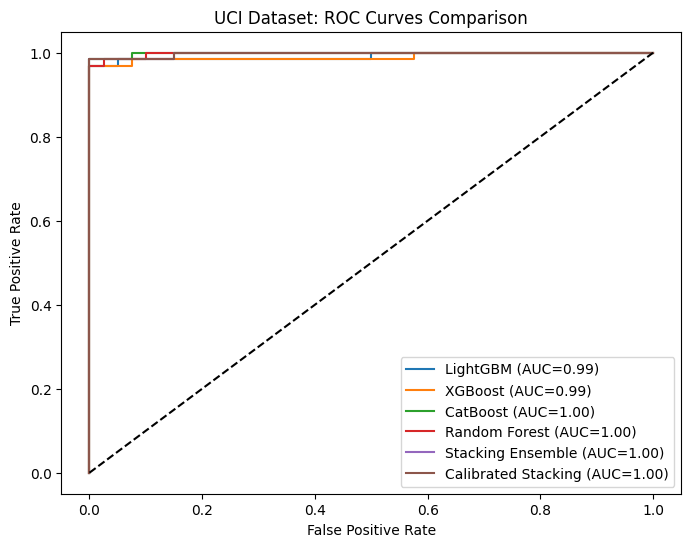


Best model (UCI): CatBoost with AUC = 0.9988

==================== Binary Dataset: Model Evaluation ====================

--- LightGBM (Binary) ---
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.91     43667
         1.0       0.42      0.42      0.42      7069

    accuracy                           0.84     50736
   macro avg       0.66      0.66      0.66     50736
weighted avg       0.84      0.84      0.84     50736

ROC-AUC: 0.8136
Sensitivity (Recall): 0.4228
Specificity: 0.9040
Brier Score: 0.1117

--- XGBoost (Binary) ---
              precision    recall  f1-score   support

         0.0       0.90      0.92      0.91     43667
         1.0       0.43      0.38      0.40      7069

    accuracy                           0.84     50736
   macro avg       0.66      0.65      0.66     50736
weighted avg       0.84      0.84      0.84     50736

ROC-AUC: 0.8130
Sensitivity (Recall): 0.3822
Specificity: 0.9168
Brier Score: 0.1093



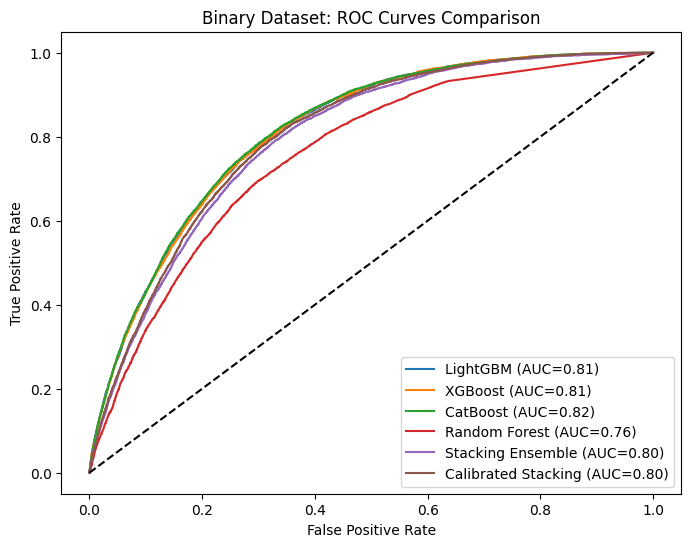


Best model (Binary): CatBoost with AUC = 0.8150


In [ ]:
# ==========================================
# 9. EVALUATION FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Model Evaluation " + "="*20)

models_uci = {
    'LightGBM': best_lgb_uci,
    'XGBoost': best_xgb_uci,
    'CatBoost': best_cat_uci,
    'Random Forest': rf_uci,
    'Stacking Ensemble': stacking_uci,
    'Calibrated Stacking': calibrated_stacking_uci
}

results_uci = {}
plt.figure(figsize=(8,6))

for name, model in models_uci.items():
    y_pred = model.predict(X_test_sel_uci)
    y_proba = model.predict_proba(X_test_sel_uci)[:, 1]

    print(f"\n--- {name} (UCI) ---")
    print(classification_report(y_test_uci, y_pred))

    auc_score = roc_auc_score(y_test_uci, y_proba)
    results_uci[name] = auc_score
    print(f"ROC-AUC: {auc_score:.4f}")

    # Additional metrics
    tn, fp, fn, tp = confusion_matrix(y_test_uci, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

    # Brier score (calibration)
    brier = brier_score_loss(y_test_uci, y_proba)
    print(f"Brier Score: {brier:.4f}")

    # ROC curve plot
    fpr, tpr, _ = roc_curve(y_test_uci, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')

# Final ROC comparison for UCI
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('UCI Dataset: ROC Curves Comparison')
plt.legend()
plt.show()

# Best model for UCI
best_model_name_uci = max(results_uci, key=results_uci.get)
print(f"\nBest model (UCI): {best_model_name_uci} with AUC = {results_uci[best_model_name_uci]:.4f}")


# ==========================================
# 9. EVALUATION FOR DIABETES BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Model Evaluation " + "="*20)

models_bin = {
    'LightGBM': best_lgb_bin,
    'XGBoost': best_xgb_bin,
    'CatBoost': best_cat_bin,
    'Random Forest': rf_bin,
    'Stacking Ensemble': stacking_bin,
    'Calibrated Stacking': calibrated_stacking_bin
}

results_bin = {}
plt.figure(figsize=(8,6))

for name, model in models_bin.items():
    y_pred = model.predict(X_test_sel_bin)
    y_proba = model.predict_proba(X_test_sel_bin)[:, 1]

    print(f"\n--- {name} (Binary) ---")
    print(classification_report(y_test_bin, y_pred))

    auc_score = roc_auc_score(y_test_bin, y_proba)
    results_bin[name] = auc_score
    print(f"ROC-AUC: {auc_score:.4f}")

    # Additional metrics
    tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

    # Brier score (calibration)
    brier = brier_score_loss(y_test_bin, y_proba)
    print(f"Brier Score: {brier:.4f}")

    # ROC curve plot
    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')

# Final ROC comparison for Binary
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary Dataset: ROC Curves Comparison')
plt.legend()
plt.show()

# Best model for Binary
best_model_name_bin = max(results_bin, key=results_bin.get)
print(f"\nBest model (Binary): {best_model_name_bin} with AUC = {results_bin[best_model_name_bin]:.4f}")

**EXPLAINABILITY WITH SHAP**


==================== UCI Dataset: SHAP Explainability ====================


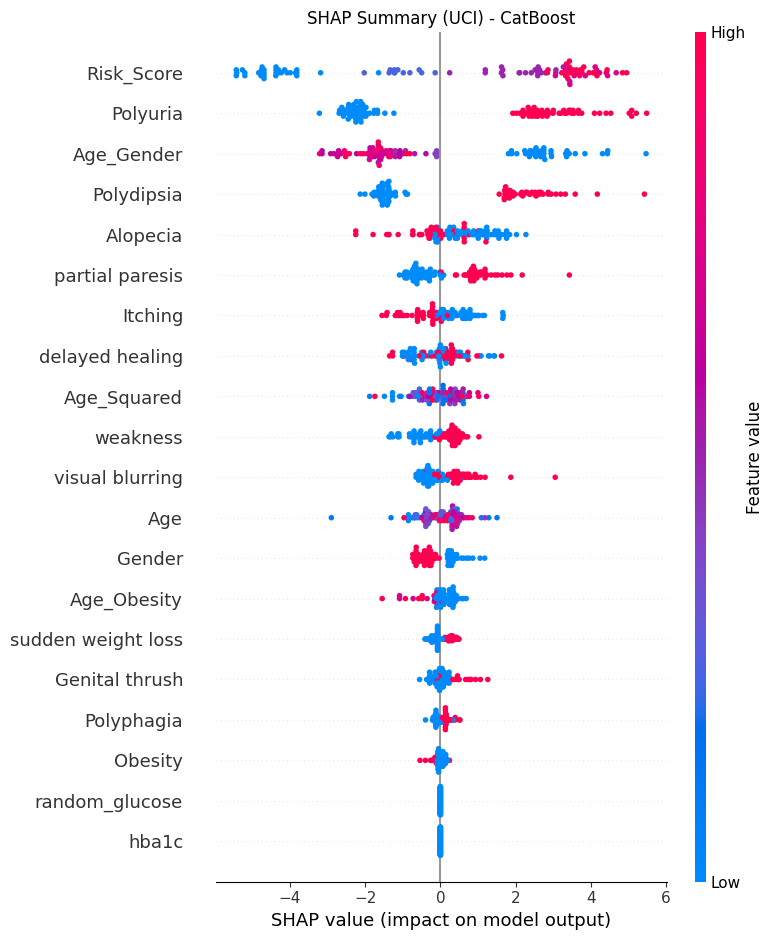


==================== Binary Dataset: SHAP Explainability ====================


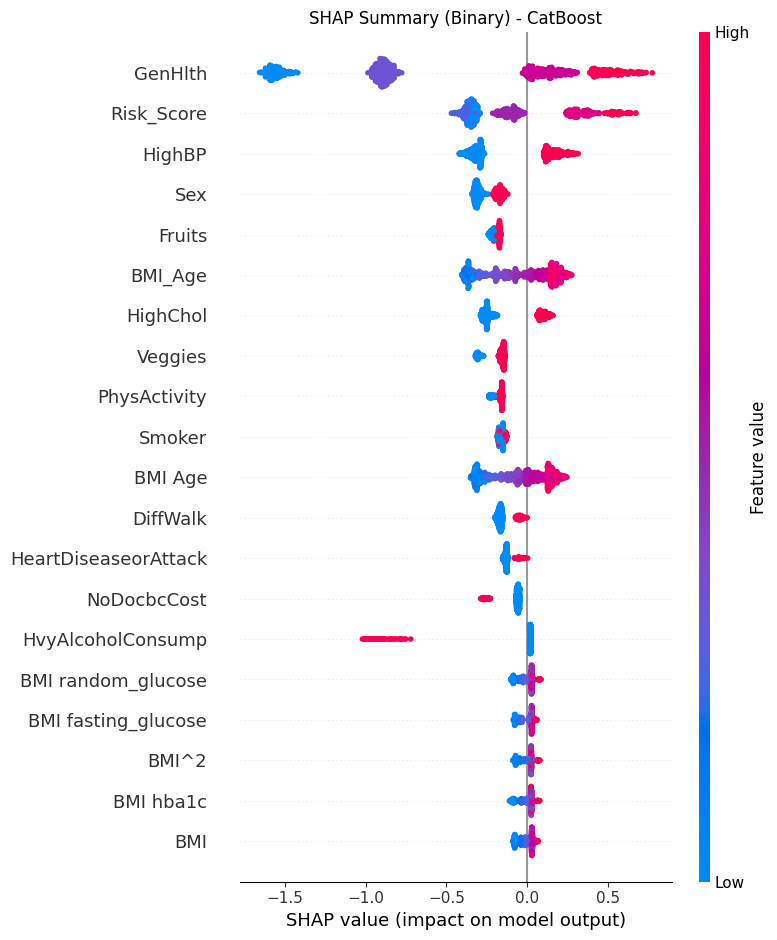

In [ ]:
import shap
shap.initjs()

# ==========================================
# 10. SHAP FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: SHAP Explainability " + "="*20)

# Determining best tree-based model for UCI
if best_model_name_uci in ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest']:
    explainer_uci = shap.TreeExplainer(models_uci[best_model_name_uci])
    shap_name_uci = best_model_name_uci
else:
    print("SHAP for Stacking/Calibrated not directly supported. Using LightGBM as proxy (UCI).")
    explainer_uci = shap.TreeExplainer(best_lgb_uci)
    shap_name_uci = "LightGBM (Proxy)"

shap_values_uci = explainer_uci.shap_values(X_test_sel_uci)

# Summary plot for UCI
plt.figure()
shap.summary_plot(shap_values_uci, X_test_sel_uci, feature_names=selected_features_uci, show=False)
plt.title(f'SHAP Summary (UCI) - {shap_name_uci}')
plt.tight_layout()
plt.show()

# ==========================================
# 10. SHAP FOR DIABETES BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: SHAP Explainability " + "="*20)

# Determining best tree-based model for Binary
if best_model_name_bin in ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest']:
    explainer_bin = shap.TreeExplainer(models_bin[best_model_name_bin])
    shap_name_bin = best_model_name_bin
else:
    print("SHAP for Stacking/Calibrated not directly supported. Using LightGBM as proxy (Binary).")
    explainer_bin = shap.TreeExplainer(best_lgb_bin)
    shap_name_bin = "LightGBM (Proxy)"

# SHAP values for Binary (Taking a subset of 1000 samples for speed due to dataset size)
X_test_subset_bin = X_test_sel_bin[:1000]
shap_values_bin = explainer_bin.shap_values(X_test_subset_bin)

# Summary plot for Binary
plt.figure()
shap.summary_plot(shap_values_bin, X_test_subset_bin, feature_names=selected_features_bin, show=False)
plt.title(f'SHAP Summary (Binary) - {shap_name_bin}')
plt.tight_layout()
plt.show()




In [ ]:
# SHAP FORCE PLOT - UCI DATASET
print("\n--- Generating Force Plot for UCI Dataset (Sample 0) ---")

# Ensure shap.initjs() is called to enable JavaScript rendering if not already active
import shap
shap.initjs()

# For UCI, we visualize the first instance of the test set
# We use the expected value and the SHAP values calculated in the previous step
shap.force_plot(
    explainer_uci.expected_value,
    shap_values_uci[0,:],
    X_test_sel_uci[0,:],
    feature_names=selected_features_uci
)


--- Generating Force Plot for UCI Dataset (Sample 0) ---


In [ ]:
# SHAP FORCE PLOT - BINARY DATASET
print("\n--- Generating Force Plot for Binary Dataset (Sample 0) ---")

# Ensure shap.initjs() is called to enable JavaScript rendering if not already active
import shap
shap.initjs()

# For the Binary dataset, we use the first instance of the subset
# calculated in the previous step (since the full dataset is too large)
shap.force_plot(
    explainer_bin.expected_value,
    shap_values_bin[0,:],
    X_test_subset_bin[0,:],
    feature_names=selected_features_bin
)


--- Generating Force Plot for Binary Dataset (Sample 0) ---


**SAVE BEST MODEL AND SCALER + RFECV**

In [ ]:
import joblib
# ==========================================
# 11. SAVING FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " Saving UCI Components " + "="*20)

joblib.dump(models_uci[best_model_name_uci], 'uci_optimized_model.pkl')
joblib.dump(scaler_uci, 'scaler_uci.pkl')
joblib.dump(rfecv_uci, 'rfecv_uci.pkl')

print("UCI optimized model saved as 'uci_optimized_model.pkl'")
print("UCI scaler saved as 'scaler_uci.pkl'")
print("UCI RFECV selector saved as 'rfecv_uci.pkl'")


# ==========================================
# 11. SAVING FOR DIABETES BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Saving Binary Components " + "="*20)

joblib.dump(models_bin[best_model_name_bin], 'binary_optimized_model.pkl')
joblib.dump(scaler_bin, 'scaler_binary.pkl')
joblib.dump(rfecv_bin, 'rfecv_binary.pkl')
joblib.dump(poly_bin, 'poly_bin.pkl') # Save the polynomial features transformer

print("Binary optimized model saved as 'binary_optimized_model.pkl'")
print("Binary scaler saved as 'scaler_binary.pkl'")
print("Binary RFECV selector saved as 'rfecv_binary.pkl'")
print("Binary PolynomialFeatures transformer saved as 'poly_bin.pkl'")


==================== Saving UCI Components ====================
UCI optimized model saved as 'uci_optimized_model.pkl'
UCI scaler saved as 'scaler_uci.pkl'
UCI RFECV selector saved as 'rfecv_uci.pkl'

==================== Saving Binary Components ====================
Binary optimized model saved as 'binary_optimized_model.pkl'
Binary scaler saved as 'scaler_binary.pkl'
Binary RFECV selector saved as 'rfecv_binary.pkl'
Binary PolynomialFeatures transformer saved as 'poly_bin.pkl'


**DEPLOYMENT DEMO**

In [ ]:
# ==========================================
# 12. DEMO FOR UCI DATASET
# ==========================================
print("\n" + "="*20 + " UCI Dataset: Demo Prediction " + "="*20)

sample_uci = X_test_sel_uci[0:1]
actual_uci = y_test_uci.iloc[0]
# Using the calibrated model for more reliable probability scores
prob_uci = calibrated_stacking_uci.predict_proba(sample_uci)[0][1]

print(f"Actual outcome: {actual_uci}")
print(f"Predicted probability of diabetes: {prob_uci:.2%}")

if prob_uci > 0.5:
    print("→ High risk (Symptomatic Profile)")
else:
    print("→ Low risk")


# ==========================================
# 12. DEMO FOR DIABETES BINARY DATASET
# ==========================================
print("\n" + "="*20 + " Binary Dataset: Demo Prediction " + "="*20)

sample_bin = X_test_sel_bin[0:1]
actual_bin = y_test_bin.iloc[0]
prob_bin = calibrated_stacking_bin.predict_proba(sample_bin)[0][1]

print(f"Actual outcome: {actual_bin}")
print(f"Predicted probability of diabetes: {prob_bin:.2%}")

if prob_bin > 0.5:
    print("→ High risk (Lifestyle/Clinical Profile)")
else:
    print("→ Low risk")

print("\nOptimized GlucoSense dual-dataset pipeline completed successfully!")


==================== UCI Dataset: Demo Prediction ====================
Actual outcome: 0
Predicted probability of diabetes: 3.36%
→ Low risk

==================== Binary Dataset: Demo Prediction ====================
Actual outcome: 0.0
Predicted probability of diabetes: 6.16%
→ Low risk

Optimized GlucoSense dual-dataset pipeline completed successfully!


**STREAMLIT APP**

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import time
import plotly.graph_objects as go
import hashlib
import os
from sklearn.preprocessing import PolynomialFeatures

# --- Constants ---
USERS_FILE = "users.csv"

# --- 1. ADVANCED UI CONFIGURATION ---
st.set_page_config(page_title="GlucoSense AI Pro", layout="wide")

# Custom CSS for Healthcare Aesthetics and Interactive Hover Effects
st.markdown("""
    <style>
    /* Target the main app container for the full background image */
    [data-testid="stAppViewContainer"] {
        background-size: cover;
        background-repeat: no-repeat;
        background-attachment: fixed;
        background-color: #FFFFFF; /* Changed to white */
    }
    /* The .stApp class usually wraps the content. Making it transparent will allow the main background to show. */
    .stApp {
        background: transparent;
    }
    /* If you want the content area to have a semi-transparent white background, you can add it to a semi-transparent white background, you could target a specific element like:
    [data-testid="stVerticalBlock"] {
        background: rgba(255, 255, 255, 0.9);
        border-radius: 10px;
        padding: 20px;
    }
    */
    .stButton>button {
        background-color: #004d4d;
        color: white;
        border-radius: 10px;
        transition: 0.3s;
    }
    .stButton>button:hover {
        background-color: #008080;
        border: 1px solid white;
    }
    </style>
    """, unsafe_allow_html=True)

# --- 2. LOAD ASSETS ---
@st.cache_resource
def load_assets():
    try:
        # These names must match your saved files from Step 11
        model_uci = joblib.load('uci_optimized_model.pkl')
        scaler_uci = joblib.load('scaler_uci.pkl')
        rfecv_uci = joblib.load('rfecv_uci.pkl')

        model_bin = joblib.load('binary_optimized_model.pkl')
        scaler_bin = joblib.load('scaler_binary.pkl')
        rfecv_bin = joblib.load('rfecv_binary.pkl')
        poly_bin = joblib.load('poly_bin.pkl') # Load the PolynomialFeatures transformer

        return model_uci, scaler_uci, rfecv_uci, model_bin, scaler_bin, rfecv_bin, poly_bin
    except Exception as e:
        st.error(f"Model artifacts not found: {e}. Please ensure all .pkl files are in the same directory.")
        return None

assets = load_assets()

# --- AUTHENTICATION FUNCTIONS ---
def make_hashes(password):
    return hashlib.sha256(str.encode(password)).hexdigest()

def check_hashes(password, hashed_text):
    return make_hashes(password) == hashed_text

def load_users():
    if not os.path.exists(USERS_FILE):
        return pd.DataFrame(columns=['username', 'password'])
    df = pd.read_csv(USERS_FILE)
    return df

def save_users(df):
    df.to_csv(USERS_FILE, index=False)

def login_page():
    st.subheader("Login to GlucoSense AI Pro")

    users_df = load_users()

    username = st.text_input("Username")
    password = st.text_input("Password", type='password')

    if st.button("Login"): # Login button
        if not users_df.empty and username in users_df['username'].values:
            stored_password_hash = users_df[users_df['username'] == username]['password'].values[0]
            if check_hashes(password, stored_password_hash):
                st.session_state['logged_in'] = True
                st.session_state['username'] = username
                st.success("Logged in Successfully!")
                st.rerun()
            else:
                st.error("Incorrect Password")
        else:
            st.error("User not found or incorrect username")

def signup_page():
    st.subheader("Create a New Account")
    new_username = st.text_input("New Username")
    new_password = st.text_input("New Password", type='password')
    confirm_password = st.text_input("Confirm Password", type='password')

    if st.button("Sign Up"): # Signup button
        if new_password == confirm_password:
            hashed_new_password = make_hashes(new_password)
            users_df = load_users()
            if new_username in users_df['username'].values:
                st.error("Username already exists. Please choose a different one.")
            else:
                new_user_df = pd.DataFrame([{'username': new_username, 'password': hashed_new_password}])
                users_df = pd.concat([users_df, new_user_df], ignore_index=True)
                save_users(users_df)
                st.success("Account created successfully! You can now log in.")
                st.rerun()
        else:
            st.error("Passwords do not match.")

# --- MAIN APP LOGIC ---
if 'logged_in' not in st.session_state:
    st.session_state['logged_in'] = False

if not st.session_state['logged_in']:
    menu = ["Login", "Sign Up"]
    choice = st.sidebar.selectbox("Authentication", menu)
    if choice == "Login":
        login_page()
    elif choice == "Sign Up":
        signup_page()
else:
    # --- LOGOUT BUTTON ---
    st.sidebar.markdown("---")
    if st.sidebar.button("Logout"):
        st.session_state['logged_in'] = False
        st.session_state['username'] = None
        st.rerun()

    # --- 3. HEADER ---
    st.title("GlucoSense AI: Professional Diagnostic Dashboard")
    st.markdown(" Painting the Future of Diabetes Care with AI in Clinical and Lifestyle Analytics")

    # Example of adding an image:
    # Ensure 'your_image.png' is in the same directory as app.py when deploying,
    # or provide a direct URL to an image.
    # st.image('your_image.png', caption='A relevant image', use_container_width=True)

    # --- 4. INPUT SECTION ---
    with st.container():
        st.subheader("📋 Patient Clinical Profile")
        st.info("AI-powered analysis utilizing combined datasets for Clinical Symptoms and Lifestyle Indicators.")

        col1, col2, col3 = st.columns(3)

        with col1:
            st.markdown("### 👤 Demographics & Basic Health Details")
            age_val = st.slider("Actual Age", 18, 90, 40)

            # Corrected mapping for age_cat
            def map_age_to_category(age):
                if 18 <= age <= 24: return 1
                elif 25 <= age <= 29: return 2
                elif 30 <= age <= 34: return 3
                elif 35 <= age <= 39: return 4
                elif 40 <= age <= 44: return 5
                elif 45 <= age <= 49: return 6
                elif 50 <= age <= 54: return 7
                elif 55 <= age <= 59: return 8
                elif 60 <= age <= 64: return 9
                elif 65 <= age <= 69: return 10
                elif 70 <= age <= 74: return 11
                elif 75 <= age <= 79: return 12
                elif age >= 80: return 13
                else: return 0 # Handle out of range, or raise an error depending on desired behavior

            age_cat = map_age_to_category(age_val)

            gender = st.selectbox("Biological Sex", ["Male", "Female"])

            bmi_option = st.radio("How would you like to provide BMI?", ("Enter BMI directly", "Calculate BMI from Height & Weight"))

            if bmi_option == "Enter BMI directly":
                bmi = st.number_input("Body Mass Index (BMI)", 10.0, 60.0, 25.0)
            else:
                height_unit = st.radio("Height Unit", ("cm", "inches"))
                weight_unit = st.radio("Weight Unit", ("kg", "lbs"))

                height_val = st.number_input(f"Height ({height_unit})", 50.0, 250.0, 170.0) # cm
                weight_val = st.number_input(f"Weight ({weight_unit})", 20.0, 200.0, 70.0) # kg

                if height_unit == "inches":
                    weight_val *= 0.453592 # Convert lbs to kg
                    height_val *= 2.54 # Convert inches to cm

                # Convert height from cm to meters for BMI calculation
                height_m = height_val / 100
                bmi = round(weight_val / (height_m ** 2), 2) if height_m > 0 else 0.0
                st.info(f"Calculated BMI: {bmi}")

            # Logic for general health rating based on BMI
            if bmi <= 25:
                gen_hlth_label = "Good (BMI <= 25)"
                gen_hlth = 3 # Mapped to Good (index 2 for 0-indexed, so 3 for 1-5 scale)
            elif bmi <= 30:
                gen_hlth_label = "Fair (25 < BMI <= 30)"
                gen_hlth = 4 # Mapped to Fair
            else:
                gen_hlth_label = "Poor (BMI > 30)"
                gen_hlth = 5 # Mapped to Poor
            st.info(f"Inferred General Health Rating based on BMI: {gen_hlth_label}")

        with col2:
            st.markdown("### ⚠️ Primary Symptoms")
            polyuria = st.toggle("Excessive Urination (Polyuria)")
            polydipsia = st.toggle("Excessive Thirst (Polydipsia)")
            polyphagia = st.toggle("Excessive Hunger (Polyphagia)")

            st.markdown("### Other Symptoms")
            weight_loss = st.toggle("Sudden Weight Loss") # Moved here
            # Renamed Genital thrush
            genital_thrush = st.toggle("Frequent Infection (Skin, Gums, Urine)") # Was 'Genital thrush'
            weakness = st.toggle("Weakness")
            blurring = st.toggle("Visual Blurring")
            itching = st.toggle("Itching")
            delayed_healing = st.toggle("Delayed Healing")
            partial_paresis = st.toggle("Partial Paresis")

            # New feature request - will not be used by trained models directly
            tingling_numbness = st.toggle("Tingling or numbness in hand or feet")
            pcos = st.toggle("PCOS (Polycystic Ovary Syndrome)") # New
            pcod = st.toggle("PCOD (Polycystic Ovarian Disease)") # New
            uti = st.toggle("UTI (Urinary Tract Infection History)") # New

            alopecia = st.toggle("Hair Loss (Alopecia)")
            obesity = st.toggle("Clinically Obese")


        with col3:
            st.markdown("### 🏃 Lifestyle Factors") # Separated section
            phys_act = st.toggle("Regular Physical Activity", value=True)
            fruits_val = st.toggle("Consumes Fruits Daily", value=True)
            veggies_val = st.toggle("Consumes Vegetables Daily", value=True)
            hvy_alcohol_consump = st.toggle("Heavy Alcohol Consumption") # Moved position
            drug_consumer = st.toggle("Drug Consumer") # New

            st.markdown("### 🏥 Clinical Risk Factors") # Separated section
            high_bp = st.toggle("Hypertension (High BP)")
            high_chol = st.toggle("High Cholesterol")
            chol_check = st.toggle("Cholesterol Check in last 5 years", value=True)
            smoker = st.toggle("Smoker (smoked 100+ cigarettes)")
            stroke = st.toggle("History of Stroke")
            heart_disease_attack = st.toggle("History of Heart Disease or Attack")
            any_healthcare_val = st.toggle("Any Healthcare Coverage", value=True) # Kept as is, explained limitation

            # The following inputs are kept for model compatibility but hidden/defaulted as per user request
            # nodocbc_cost_val is removed from UI, defaulting to 0
            # diff_walk is removed from UI, defaulting to 0
            # phys_hlth label is kept as is, explained limitation

            # education_val = st.selectbox("Education Level", options=[1,2,3,4,5,6],
            #                            format_func=lambda x: {1:'No schooling', 2:'Elementary', 3:'Some high school', 4:'High school grad', 5:'Some college', 6:'College grad'}[x], index=3)
            education_val = 5.0 # Defaulting to 'Some college' for model input

            # income_val = st.selectbox("Income Level", options=[1,2,3,4,5,6,7,8],
            #                         format_func=lambda x: {1:'< $10k', 2:'$10k-15k', 3:'$15k-20k', 4:'$20k-25k', 5:'$25k-35k', 6:'$35k-50k', 7:'$50k-75k', 8:'> $75k'}[x], index=3)
            income_val = 6.0 # Defaulting to '$35k-50k' for model input

            # ment_hlth = st.slider("Days of poor mental health (last 30)", 0, 30, 0)
            ment_hlth = 0.0 # Defaulting to 0 for model input

            # phys_hlth = st.slider("Days of poor physical health (last 30)", 0, 30, 0) # Kept as is, explained limitation
            phys_hlth = 0.0 # Defaulting to 0 for model input

            st.markdown("### 🩸 Blood Sugar Readings")
            fasting_glucose = st.number_input("Fasting Plasma Glucose (mg/dL)", min_value=0.0, value=90.0, step=1.0)
            random_glucose = st.number_input("Random Plasma Glucose (mg/dL)", min_value=0.0, value=120.0, step=1.0)
            hba1c = st.number_input("HbA1c (%)", min_value=0.0, max_value=20.0, value=5.5, step=0.1)


    # Define dummy doctor information
    doctors_info = [
        {"name": "Dr. Rohan Mehta", "Specialty": "Diabetologist", "Phone": "+91 98765 43210", "Address": "402, Silver Heights Building, MG Road, Sector 12, Pune, Maharashtra – 411001"},
        {"name": "Dr. Priya Sharma", "Specialty": "Diabetes/Asthma", "Phone": "+91 91234 56789", "Address": "Plot No. 18, Green Park Colony, Jaipur, Rajasthan – 302017"}
    ]

    # --- 7. DIAGNOSIS SECTION (Now integrated into main analysis) ---
    st.markdown("---")

    # --- 5. INFERENCE ENGINE (Combined Logic) ---
    if st.button("🚀 GENERATE RISK ANALYSIS", use_container_width=True):
        if assets:
            m_uci, s_uci, r_uci, m_bin, s_bin, r_bin, poly_bin = assets

            with st.spinner('Synchronizing clinical data...'):
                time.sleep(1)

                # --- 1. PREPARE UCI DATA (Expecting 22 features for scaler_uci) ---
                # Order must match X_uci after preprocessing but BEFORE RFECV.
                # Original base features (14 after dropping 'Irritability' and 'muscle stiffness') + 4 new features:
                # Age, Gender, Polyuria, Polydipsia, sudden weight loss, weakness, Polyphagia,
                # Genital thrush, visual blurring, Itching, delayed healing, partial paresis, Alopecia, Obesity
                # + tingling_numbness, fasting_glucose, random_glucose, hba1c
                uci_base_features = [
                    age_val,
                    1 if gender == "Male" else 0, # Gender
                    int(polyuria),
                    int(polydipsia),
                    int(weight_loss),
                    int(weakness),
                    int(polyphagia),
                    int(genital_thrush),
                    int(blurring),
                    int(itching),
                    int(delayed_healing),
                    int(partial_paresis),
                    int(alopecia),
                    int(obesity),
                    int(tingling_numbness), # Added to match trained features
                    fasting_glucose,        # Added to match trained features
                    random_glucose,         # Added to match trained features
                    hba1c                   # Added to match trained features
                ] # This is 18 features

                # Engineered features for UCI (4 features)
                age_obesity = age_val * int(obesity)
                age_gender = age_val * (1 if gender == "Male" else 0)
                age_squared = age_val ** 2
                # CORRECTED: Risk_Score for UCI should include all symptoms used in training
                risk_score_uci = sum([
                    int(polyuria),
                    int(polydipsia),
                    int(weight_loss),
                    int(polyphagia),
                    int(obesity),
                    int(tingling_numbness) # Added for consistency with training
                ])

                # Combine base and engineered features (18 + 4 = 22 features)
                uci_full = np.array(uci_base_features +
                                    [age_obesity, age_gender, age_squared, risk_score_uci]).reshape(1, -1)

                # Transform and Predict UCI
                uci_scaled = s_uci.transform(uci_full)
                uci_selected = r_uci.transform(uci_scaled)
                uci_p = m_uci.predict_proba(uci_selected)[0][1]

                # --- 2. PREPARE BINARY DATA (Expecting 45 features for scaler_bin) ---
                # Order must match X_bin after preprocessing but BEFORE RFECV.
                # Base features + Synthetic features (17 + 6 = 23 features):
                bin_initial_features = [
                    float(high_bp),
                    float(high_chol),
                    float(chol_check),
                    bmi,
                    float(smoker),
                    float(stroke),
                    float(heart_disease_attack),
                    float(phys_act),
                    float(fruits_val),
                    float(veggies_val),
                    float(hvy_alcohol_consump),
                    float(any_healthcare_val),
                    0.0, # NoDocbcCost
                    float(gen_hlth),
                    0.0, # DiffWalk
                    1.0 if gender == "Male" else 0.0,
                    float(age_cat),
                    # Synthetic features added to df_binary during training
                    float(pcos or pcod), # Combine PCOS and PCOD as per training logic
                    float(uti),
                    float(drug_consumer),
                    fasting_glucose,
                    random_glucose,
                    hba1c
                ] # This list should now have 23 features

                # Engineered Features for Binary:
                bmi_age = bmi * age_cat # 1 feature

                # Polynomial features (20 features) - Input must match `key_feat_bin` used during training.
                # `key_feat_bin = ['BMI', 'Age', 'fasting_glucose', 'random_glucose', 'hba1c']`
                poly_input_vals = np.array([[bmi, float(age_cat), fasting_glucose, random_glucose, hba1c]])
                # Use the loaded poly_bin object
                poly_features_vals_full = poly_bin.transform(poly_input_vals)[0]

                # Risk Score (1 feature)
                risk_score_bin = (
                    float(high_bp) +
                    float(high_chol) +
                    (1.0 if bmi > 30 else 0.0) +
                    (1.0 if age_cat > 8 else 0.0) +
                    (1.0 if pcos or pcod else 0.0) +
                    float(uti) +
                    float(drug_consumer)
                )

                # Combine all 45 features in the correct order
                bin_full = np.array(
                    bin_initial_features +
                    [bmi_age] +
                    poly_features_vals_full.tolist() +
                    [risk_score_bin]
                ).reshape(1, -1)

                # Transform and Predict Binary
                bin_scaled = s_bin.transform(bin_full)
                bin_selected = r_bin.transform(bin_scaled)
                bin_p = m_bin.predict_proba(bin_selected)[0][1]

                # --- 3. COMBINED RESULTS ---
                final_risk = (uci_p + bin_p) / 2

                # --- Blood Sugar Diagnosis Logic (moved here) ---
                is_diabetic_fasting = fasting_glucose >= 126
                is_diabetic_random = random_glucose >= 200
                is_diabetic_hba1c = hba1c >= 6.5
                is_diabetic_clinical = is_diabetic_fasting or is_diabetic_random or is_diabetic_hba1c

                # --- 6. DISPLAY RESULTS ---
                st.markdown("---")
                st.subheader("🔬 Combined Risk & Diagnosis Analysis")

                res_col1, res_col2 = st.columns([1, 1])

                with res_col1:
                    fig = go.Figure(go.Indicator(
                        mode = "gauge+number",
                        value = final_risk * 100,
                        title = {'text': "Diabetes Risk Score (%)"},
                        gauge = {'axis': {'range': [0, 100]},
                                 'bar': {'color': "#004d4d"},
                                 'steps': [
                                     {'range': [0, 30], 'color': "lightgreen"},
                                     {'range': [30, 70], 'color': "orange"},
                                     {'range': [70, 100], 'color': "red"}]}))
                    st.plotly_chart(fig, use_container_width=True)

                with res_col2:
                    st.markdown("#### Diagnostic Summary")

                    if is_diabetic_clinical:
                        st.error("🔴 **Based on your blood sugar readings, you meet the criteria for Diabetes.**")
                        st.markdown("- Fasting Plasma Glucose: {} mg/dL ({}126 mg/dL)".format(fasting_glucose, ">= " if is_diabetic_fasting else "<"))
                        st.markdown("- Random Plasma Glucose: {} mg/dL ({}200 mg/dL)".format(random_glucose, ">= " if is_diabetic_random else "<"))
                        st.markdown("- HbA1c: {}% ({}6.5%)".format(hba1c, ">= " if is_diabetic_hba1c else "<"))
                        st.warning("**Please consult with a healthcare professional for confirmation and management.**")

                        # DISCREPANCY MESSAGE: Clinical Diagnosis is Positive, but AI Risk is Low
                        if final_risk <= 0.35: # Assuming 0.35 is your 'low risk' threshold
                            st.markdown("---")
                            st.warning("**Important Discrepancy Note:** Your blood sugar readings indicate diabetes, but your overall AI risk score (below) is currently low. This suggests a recent onset or that your broader risk factors have not yet fully developed. **The clinical diagnosis from blood sugar takes precedence for immediate health action. Consult a doctor without delay.**")
                            st.markdown("---")

                    else:
                        st.success("✅ **Based on your blood sugar readings, you do not meet the diagnostic criteria for Diabetes.**")
                        st.markdown("- Fasting Plasma Glucose: {} mg/dL (< 126 mg/dL)".format(fasting_glucose))
                        st.markdown("- Random Plasma Glucose: {} mg/dL (< 200 mg/dL)".format(random_glucose))
                        st.markdown("- HbA1c: {}% (< 6.5%)".format(hba1c))
                        st.info("Continue regular check-ups and maintain a healthy lifestyle.")

                    st.markdown("#### AI-Predicted Overall Diabetes Risk")

                    if final_risk > 0.7:
                        st.error("🚨 **HIGH RISK**")
                        st.markdown("**:red[Immediate medical consultation strongly recommended. Discuss risk factors and develop a comprehensive health plan with your doctor.]**")
                        st.markdown("...") # Ellipsis for brevity, existing doctor info will follow

                    elif final_risk > 0.35:
                        st.warning("⚠️ **MODERATE RISK**")
                        st.markdown("**:orange[Consider consulting your doctor for further assessment. Focus on lifestyle changes including diet and exercise.]**")
                    else:
                        st.success("✅ **LOW RISK**")
                        st.markdown("**:green[Maintain a healthy lifestyle with regular check-ups. Continue to monitor risk factors.]**")

                    st.write(f"Confidence (Symptoms-Based): {uci_p:.1%}")
                    st.write(f"Confidence (Lifestyle/Clinical-Based): {bin_p:.1%}")

                    st.markdown("#### Primary Risk Indication:")
                    if uci_p > bin_p and uci_p > 0.5:
                        st.info("Your risk is primarily indicated by **symptomatic factors**. These may include immediate physical signs of potential diabetes. Please discuss these symptoms with a healthcare professional.")
                    elif bin_p > uci_p and bin_p > 0.5:
                        st.info("""Your risk is primarily indicated by **lifestyle and clinical factors**. These may include diet, activity levels, existing conditions like high blood pressure, etc. Lifestyle modifications and regular clinical monitoring are important.
                        """)
                    elif uci_p > 0.35 and bin_p > 0.35:
                        st.info("Your risk shows significant contributions from **both symptomatic and lifestyle and clinical factors**. A holistic approach to management is advised.")
                    else:
                        st.info("Risk factors are currently low based on the provided information. Continue healthy habits.")

                    # Moved doctor info to be displayed when risk is high
                    if final_risk > 0.7:
                        st.markdown("---")
                        st.markdown("#### Recommended Doctors:")
                        for doctor in doctors_info:
                            st.markdown(f"**{doctor['name']}** ({doctor['Specialty']})")
                            st.markdown(f"Phone: {doctor['Phone']}")
                            st.markdown(f"Address: {doctor['Address']}")
                            st.markdown("")

    # --- FOOTER ---
    st.markdown("---")
    st.caption("© 2026 GlucoSense AI Labs | For Academic Research")

Overwriting app.py


In [ ]:
from google.colab import files
import os

# Create a list of all model, scaler, and selector files
files_to_download = [f for f in os.listdir('.') if f.endswith('.pkl') or f == 'app.py']

if len(files_to_download) == 0:
    print("No files found. Please make sure you ran the training loop first!")
else:
    # Zip the files so you only have to download one thing
    !zip -r GlucoSense_Files.zip {' '.join(files_to_download)}
    # Trigger the browser download
    files.download('GlucoSense_Files.zip')

updating: rfecv_binary.pkl (deflated 83%)
updating: app.py (deflated 69%)
updating: binary_optimized_model.pkl (deflated 58%)
updating: scaler_binary.pkl (deflated 38%)
updating: scaler_uci.pkl (deflated 31%)
updating: rfecv_uci.pkl (deflated 82%)
updating: uci_optimized_model.pkl (deflated 98%)
  adding: poly_bin.pkl (deflated 36%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>